In [96]:
import pandas as pd

# 데이터 로드
residual1 = pd.read_csv('data/residual_features_frac_0.4.csv')
residual2 = pd.read_csv('data/residual_features_frac_0.5.csv')
residual3 = pd.read_csv('data/residual_features_frac_0.6.csv')

# datasets 딕셔너리 생성
datasets = {
    0.1: residual1.copy(),
    0.2: residual2.copy(),
    0.3: residual3.copy()
}

In [97]:
from copulas.multivariate import GaussianMultivariate

# 사용할 데이터셋 선택
df = datasets[0.1].copy()

# 상태 컬럼 자동 탐색
if 'status' in df.columns:
    status_col = 'status'
elif 'Status' in df.columns:
    status_col = 'Status'
else:
    raise ValueError("status 또는 Status 컬럼이 데이터에 없습니다.")

# feature 컬럼
feature_cols = ['0', '1', '2', '3', '4', '5']

# 컬럼 존재 여부 확인
missing_features = [c for c in feature_cols if c not in df.columns]
if missing_features:
    raise ValueError(f"다음 feature 컬럼이 없습니다: {missing_features}")

# train / test 분리
train_df = df[df[status_col] == 'train'].copy()
test_df = df[df[status_col] != 'train'].copy()

print("status column:", status_col)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print(train_df[status_col].value_counts(dropna=False))
print(test_df[status_col].value_counts(dropna=False))


status column: status
train shape: (200, 8)
test shape: (200, 8)
status
train    200
Name: count, dtype: int64
status
Normal     120
Damaged     80
Name: count, dtype: int64


In [98]:
from copulas.multivariate import GaussianMultivariate
import pandas as pd
import numpy as np

def get_valid_columns(sample):
    """NaN이 아닌 관측 컬럼 목록 반환"""
    return sample.dropna().index.tolist()

def fit_subset_copula(train_data_subset):
    """부분 feature에 대한 Gaussian copula 모델 학습"""
    model = GaussianMultivariate()
    model.fit(train_data_subset)
    return model

def get_marginal_density_cached(train_data, sample, cache):
    """
    sample에서 관측된 컬럼만 사용하여
    부분 Gaussian copula 모델의 density를 계산합니다.

    Parameters
    ----------
    train_data : pd.DataFrame
        train 데이터의 feature 부분만 포함
    sample : pd.Series
        단일 샘플 (feature_cols만 포함된 형태 권장)
    cache : dict
        key = tuple(valid_cols), value = fitted GaussianMultivariate
    """
    valid_cols = get_valid_columns(sample)

    # 모든 값이 결측이면 density 계산 불가
    if len(valid_cols) == 0:
        return np.nan, tuple()

    key = tuple(valid_cols)

    # 같은 관측 패턴은 모델 재사용
    if key not in cache:
        sub_train = train_data.loc[:, valid_cols].copy()

        # 혹시 train 쪽에 NaN이 남아 있으면 제거
        sub_train = sub_train.dropna(axis=0)

        # 데이터가 너무 적으면 모델 학습이 불안정할 수 있음
        if len(sub_train) < 5:
            return np.nan, key

        sub_model = fit_subset_copula(sub_train)
        cache[key] = sub_model

    sub_model = cache[key]

    # 단일 샘플을 1행 DataFrame으로 구성
    sub_sample = pd.DataFrame(
        [sample.loc[valid_cols].values],
        columns=valid_cols
    )

    density_raw = sub_model.probability_density(sub_sample)
    density = np.asarray(density_raw).reshape(-1)[0]

    # numerical safety
    if density <= 0 or not np.isfinite(density):
        density = 1e-300

    return density, key


In [99]:
train_data = train_df[feature_cols].copy()
test_data = test_df[feature_cols].copy()

cache = {}
results = []

for idx, row in test_df.iterrows():
    sample = row[feature_cols]

    density, pattern = get_marginal_density_cached(train_data, sample, cache)

    results.append({
        'index': idx,
        'status': row[status_col],
        'density': density,
        'log_density': np.log(max(density, 1e-300)),
        'n_observed': sample.notna().sum(),
        'observed_pattern': pattern
    })

results_df = pd.DataFrame(results)

print(results_df.head())
print("number of cached subset models:", len(cache))


c:\Users\jaeseok\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_continuous_distns.py:785: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Users\jaeseok\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_continuous_distns.py:790: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
c:\Users\jaeseok\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_continuous_distns.py:785: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Users\jaeseok\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_continuous_distns.py:790: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  a, b = optimize.fsolve(func

   index  status   density  log_density  n_observed observed_pattern
0    200  Normal  0.001082    -6.828547           4     (1, 2, 3, 5)
1    201  Normal  0.023086    -3.768523           3        (0, 2, 3)
2    202  Normal  0.000358    -7.935772           5  (0, 1, 2, 3, 5)
3    203  Normal  0.011151    -4.496211           3        (0, 1, 4)
4    204  Normal  0.008118    -4.813625           5  (0, 2, 3, 4, 5)
number of cached subset models: 57


In [100]:
print(results_df.groupby('status')[['density', 'log_density', 'n_observed']].agg(['mean', 'std', 'median']))


          density                         log_density                        \
             mean       std        median        mean        std     median   
status                                                                        
Damaged  0.002943  0.016787  1.884552e-12  -27.555055  13.050710 -27.020960   
Normal   0.008542  0.020471  1.513470e-03   -6.580530   2.326916  -6.493354   

        n_observed                   
              mean       std median  
status                               
Damaged   3.437500  1.123329    3.5  
Normal    3.741667  1.155883    4.0  


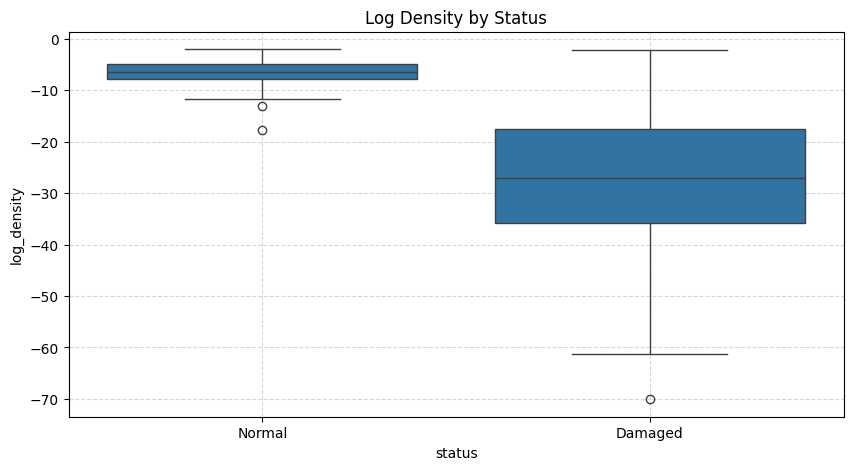

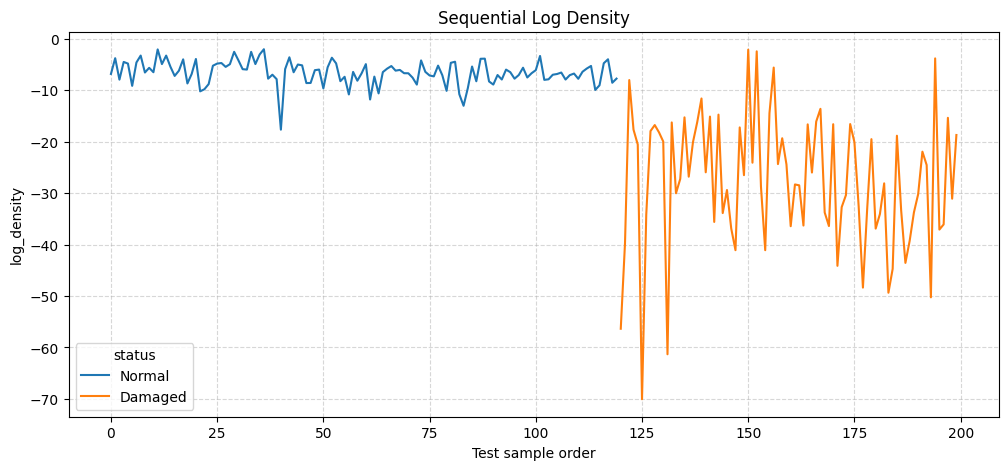

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(data=results_df, x='status', y='log_density')
plt.title('Log Density by Status')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(data=results_df, x=np.arange(len(results_df)), y='log_density', hue='status')
plt.title('Sequential Log Density')
plt.xlabel('Test sample order')
plt.ylabel('log_density')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [102]:
import numpy as np
import pandas as pd

# -----------------------------
# 1) Train threshold 계산
# -----------------------------
train_data = train_df[feature_cols].copy()
train_cache = {}
train_log_densities = []

for idx, row in train_df.iterrows():
    sample = row[feature_cols]
    density, pattern = get_marginal_density_cached(train_data, sample, train_cache)
    log_density = np.log(max(density, 1e-300))
    train_log_densities.append(log_density)

train_threshold = np.percentile(train_log_densities, 1)

# -----------------------------
# 2) Test prediction
# -----------------------------
results_df = results_df.copy()
results_df['prediction'] = (results_df['log_density'] < train_threshold).astype(int)

# -----------------------------
# 3) 성능 평가
# -----------------------------
val_section = results_df.iloc[:120].copy()
damage_section = results_df.iloc[120:].copy()

far = val_section['prediction'].mean() * 100 if len(val_section) > 0 else np.nan
dr = damage_section['prediction'].mean() * 100 if len(damage_section) > 0 else np.nan

print(f"--- Performance Analysis ---")
print(f"Threshold (1st percentile of train log_density): {train_threshold:.4f}")
print(f"Validation samples: {len(val_section)}")
print(f"Damage samples: {len(damage_section)}")
print(f"False Alarm Rate (FAR): {far:.2f}%")
print(f"Detection Rate (DR): {dr:.2f}%")


c:\Users\jaeseok\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_continuous_distns.py:785: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Users\jaeseok\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_continuous_distns.py:790: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
c:\Users\jaeseok\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_continuous_distns.py:785: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Users\jaeseok\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_continuous_distns.py:790: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  a, b = optimize.fsolve(func

--- Performance Analysis ---
Threshold (1st percentile of train log_density): -13.8561
Validation samples: 120
Damage samples: 80
False Alarm Rate (FAR): 0.83%
Detection Rate (DR): 91.25%


결측치 40%까지는 90%이사을 유지, 경험적 분위수를 적용하고 있는데, 결측치가 높아질 수록 계속 이상치가 높아짐, 임계치의 범위가 넓어져서 탐지율 성능이 떨어짐

임계치 산정 방식에 대한 점검이 필요, log_density